# K-Nearest Neighbors (K-NN)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
dataset = pd.read_csv('/protein.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

X = imputer.fit_transform(X)

nan_in_y_indices = np.where(np.isnan(y))[0]

if len(nan_in_y_indices) > 0:
    print(f"Removing {len(nan_in_y_indices)} rows due to NaN in target variable y.")
    X = np.delete(X, nan_in_y_indices, axis=0)
    y = np.delete(y, nan_in_y_indices, axis=0)
    print(f"Shape of X after removing NaNs from y: {X.shape}")
    print(f"Shape of y after removing NaNs from y: {y.shape}")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

dataset = pd.read_csv('/protein.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X = imputer.fit_transform(X)

nan_in_y_indices = np.where(np.isnan(y))[0]
if len(nan_in_y_indices) > 0:
    X = np.delete(X, nan_in_y_indices, axis=0)
    y = np.delete(y, nan_in_y_indices, axis=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
classifier = KNeighborsRegressor(n_neighbors = 5,
                                  metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

KNeighborsRegressor()

In [ ]:
print(classifier.predict(sc.transform([[30, 87000, 0, 0, 0, 0, 0, 0, 0]])))

[25.84378]


In [ ]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[37.182   37.5904 ]
 [31.279   30.382  ]
 [43.90508 44.4937 ]
 ...
 [20.98144 21.1112 ]
 [41.53334 42.0062 ]
 [35.1504  35.365  ]]


In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 3.88


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
classifier = KNeighborsRegressor(n_neighbors = 5,
                                  metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

KNeighborsRegressor()

In [ ]:
print(classifier.predict(sc.transform([[30, 87000, 0, 0, 0, 0, 0, 0, 0]])))

[25.84378]


In [ ]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[37.182   37.5904 ]
 [31.279   30.382  ]
 [43.90508 44.4937 ]
 ...
 [20.98144 21.1112 ]
 [41.53334 42.0062 ]
 [35.1504  35.365  ]]


In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 3.88


In [ ]:
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
print(X1)
print(X2)

[[-10.  -9.  -8. ...  28.  29.  30.]
 [-10.  -9.  -8. ...  28.  29.  30.]
 [-10.  -9.  -8. ...  28.  29.  30.]
 ...
 [-10.  -9.  -8. ...  28.  29.  30.]
 [-10.  -9.  -8. ...  28.  29.  30.]
 [-10.  -9.  -8. ...  28.  29.  30.]]
[[ 1392.05  1392.05  1392.05 ...  1392.05  1392.05  1392.05]
 [ 1393.05  1393.05  1393.05 ...  1393.05  1393.05  1393.05]
 [ 1394.05  1394.05  1394.05 ...  1394.05  1394.05  1394.05]
 ...
 [41032.05 41032.05 41032.05 ... 41032.05 41032.05 41032.05]
 [41033.05 41033.05 41033.05 ... 41033.05 41033.05 41033.05]
 [41034.05 41034.05 41034.05 ... 41034.05 41034.05 41034.05]]


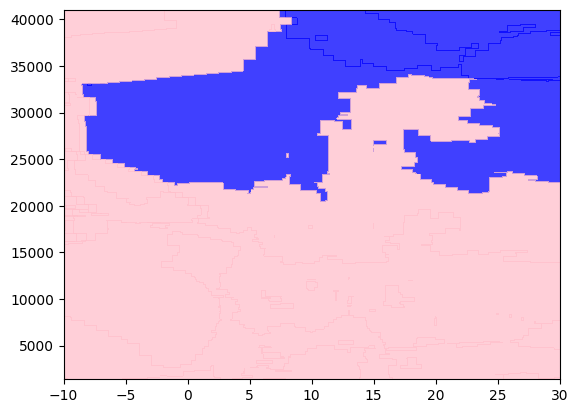

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))

X_other_features_mean = np.mean(X_set[:, 2:], axis=0)

meshgrid_points = np.zeros((X1.size, X_set.shape[1]))
meshgrid_points[:, 0] = X1.ravel()
meshgrid_points[:, 1] = X2.ravel()

for i in range(len(X_other_features_mean)):
    meshgrid_points[:, i + 2] = X_other_features_mean[i]

Z = classifier.predict(sc.transform(meshgrid_points)).reshape(X1.shape)

plt.contourf(X1, X2, Z,
             alpha = 0.75, cmap = ListedColormap(('blue', 'pink')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.show()

In [ ]:
X_set, y_set = sc.inverse_transform(X_train), y_train

In [ ]:
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))

In [ ]:
print(X1)
print(X2)

[[-10.  -9.  -8. ...  28.  29.  30.]
 [-10.  -9.  -8. ...  28.  29.  30.]
 [-10.  -9.  -8. ...  28.  29.  30.]
 ...
 [-10.  -9.  -8. ...  28.  29.  30.]
 [-10.  -9.  -8. ...  28.  29.  30.]
 [-10.  -9.  -8. ...  28.  29.  30.]]
[[ 1392.05  1392.05  1392.05 ...  1392.05  1392.05  1392.05]
 [ 1393.05  1393.05  1393.05 ...  1393.05  1393.05  1393.05]
 [ 1394.05  1394.05  1394.05 ...  1394.05  1394.05  1394.05]
 ...
 [41032.05 41032.05 41032.05 ... 41032.05 41032.05 41032.05]
 [41033.05 41033.05 41033.05 ... 41033.05 41033.05 41033.05]
 [41034.05 41034.05 41034.05 ... 41034.05 41034.05 41034.05]]


## Visualising the Test set results

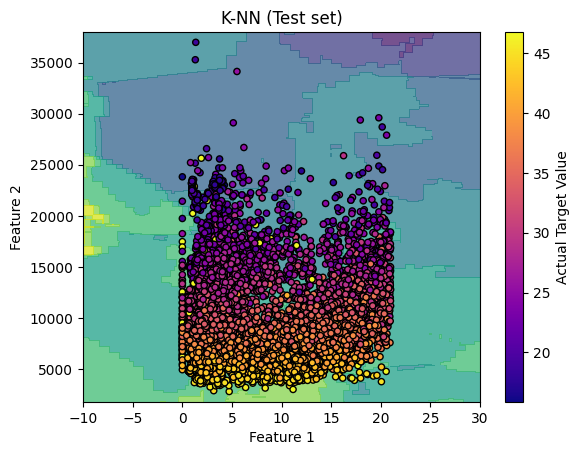

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))

X_other_features_mean = np.mean(sc.inverse_transform(X_train)[:, 2:], axis=0)

meshgrid_points = np.zeros((X1.size, X_set.shape[1]))
meshgrid_points[:, 0] = X1.ravel()
meshgrid_points[:, 1] = X2.ravel()

for i in range(len(X_other_features_mean)):
    meshgrid_points[:, i + 2] = X_other_features_mean[i]

Z = classifier.predict(sc.transform(meshgrid_points)).reshape(X1.shape)

plt.contourf(X1, X2, Z,
             alpha = 0.75, cmap = 'viridis')
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

scatter = plt.scatter(X_set[:, 0], X_set[:, 1], c = y_set, cmap = 'plasma', s=20, edgecolors='k')
plt.colorbar(scatter, label='Actual Target Value')

plt.title('K-NN (Test set)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()